# Python and CLI for Data Science - Session 11

- *Course*: Python and CLI for Data Science
- *Session*: 11
- *Unit*: Matplotlib Subplots

### (Re)sources:
- [Python Data Science Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/index.html) _by Jake VanderPlas (Code released under the MIT License)_

In [ ]:
import io

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests


def download(name: str) -> pd.DataFrame:
    url = f"https://raw.githubusercontent.com/mwaskom/seaborn-data/master/{name}.csv"
    return pd.read_csv(io.StringIO(requests.get(url).text))

# Multiple Subplots

- Sometimes it is helpful to compare different views of data side by side
- Matplotlib has the concept of *subplots*: groups of smaller axes that can exist together within a single figure
- These subplots might be insets, grids of plots, or other more complicated layouts

## plt.axes: Subplots by Hand

- The most basic method of creating an axes is to use the `plt.axes` function
- `plt.axes` also takes an optional argument that is a list of four numbers in the figure coordinate system (`[left, bottom, width, height]`), which ranges from 0 at the bottom left of the figure to 1 at the top right of the figure

In [ ]:
ax1 = plt.axes()  # standard axes
ax2 = plt.axes([0.65, 0.65, 0.2, 0.2])

- The equivalent of this command within the object-oriented interface is `fig.add_axes`
- Let's use this to create two vertically stacked axes, as seen in the following figure

In [ ]:
fig = plt.figure()
ax1 = fig.add_axes([0.1, 0.5, 0.8, 0.4], xticklabels=[], ylim=(-1.2, 1.2))
ax2 = fig.add_axes([0.1, 0.1, 0.8, 0.4], ylim=(-1.2, 1.2))

x = np.linspace(0, 10)
ax1.plot(np.sin(x))
ax2.plot(np.cos(x))

## plt.subplot: Simple Grids of Subplots

- Matplotlib has several convenience routines that make creating aligned columns or rows of subplots easy
- The lowest level of these is `plt.subplot`, which creates a single subplot within a grid
- This command takes three integer arguments:
    1. the number of rows
    2. the number of columns
    3. and the index of the plot to be created in this scheme

In [ ]:
for i in range(1, 7):
    plt.subplot(2, 3, i)
    plt.text(0.5, 0.5, str((2, 3, i)), fontsize=18, ha="center")

## plt.subplots: The Whole Grid in One Go

- When creating multiple sublpots, `plt.subplots` is the easier tool to use (note the `s` at the end of `subplots`)
- Rather than creating a single subplot, this function creates a full grid of subplots in a single line, returning them in a NumPy array
- The arguments are the number of rows and number of columns, along with optional keywords `sharex` and `sharey`, which allow you to specify the relationships between different axes

In [ ]:
fig, ax = plt.subplots(2, 3, sharex="col", sharey="row")

- By specifying `sharex` and `sharey`, we've automatically removed inner labels on the grid to make the plot cleaner
- The resulting grid of axes instances is returned within a NumPy array, allowing for convenient specification of the desired axes using standard array indexing notation

In [ ]:
# axes are in a two-dimensional array, indexed by [row, col]
for i in range(2):
    for j in range(3):
        ax[i, j].text(0.5, 0.5, str((i, j)), fontsize=18, ha="center")
fig

## plt.GridSpec: More Complicated Arrangements

- To go beyond a regular grid to subplots that span multiple rows and columns, `plt.GridSpec` is the best tool
- `plt.GridSpec` does not create the grid but is a convenient interface that is recognized by the `plt.subplot` command
- For example, a `GridSpec` for a grid of two rows and three columns with some specified width and height space looks like this

In [ ]:
grid = plt.GridSpec(2, 3, wspace=0.4, hspace=0.3)

- From this we can specify subplot locations and extents using the familiar Python slicing syntax

In [ ]:
plt.subplot(grid[0, 0])
plt.subplot(grid[0, 1:])
plt.subplot(grid[1, :2])
plt.subplot(grid[1, 2])

- This type of flexible grid alignment has a wide range of uses
- For example, it allows combining histograms and scatter plots into a single figure

In [ ]:
# Create some normally distributed data
x, y = np.random.multivariate_normal([0, 0], [[1, 1], [1, 2]], 3000).T

# Set up the axes with GridSpec
fig = plt.figure(figsize=(6, 6))
grid = plt.GridSpec(4, 4, hspace=0.2, wspace=0.2)
main_ax = fig.add_subplot(grid[:-1, 1:])
y_hist = fig.add_subplot(grid[:-1, 0], xticklabels=[], sharey=main_ax)
x_hist = fig.add_subplot(grid[-1, 1:], yticklabels=[], sharex=main_ax)

# Scatter points on the main axes
main_ax.plot(x, y, "ok", markersize=3, alpha=0.2)

# Histogram on the attached axes
x_hist.hist(x, 40, histtype="stepfilled", orientation="vertical", color="gray")
x_hist.invert_yaxis()
y_hist.hist(y, 40, histtype="stepfilled", orientation="horizontal", color="gray")
y_hist.invert_xaxis()

# Exercise

Repeat the exercise for the titanic task, but this time, include all pie charts into a single figure using subplots. Your figure could/should look something like this:

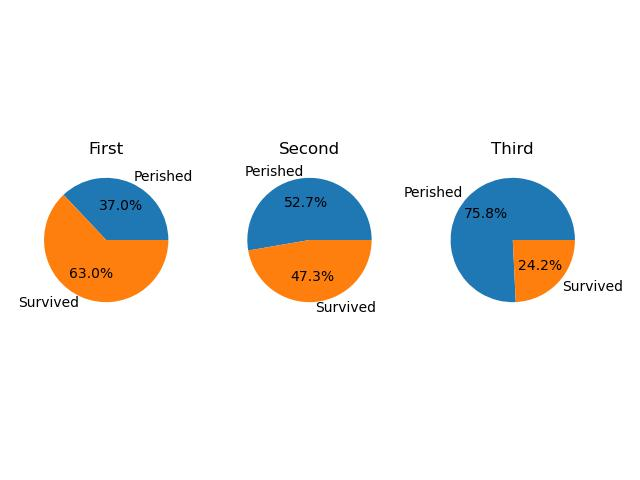

In [ ]:
titanic = download("titanic")
titanic

In [ ]:
# Solve the exercise here

In [ ]:
variable = "class"
survived = titanic.groupby(variable)["survived"].value_counts().sort_index()
survived = survived.rename({1: "Survived", 0: "Perished"})
labels = survived.index.levels[0]

fig, axs = plt.subplots(1, len(labels), layout="tight")

for label, ax in zip(labels, axs):
    ax.set_title(label.title())
    df = survived[label]
    ax.pie(df, labels=df.index, autopct="%1.1f%%")